## <font color="royalblue">**Visualización de datos**</font>
Visualizacion de los datos obtenidos del analisis NLP, para los portales de empleo. Seran consideradas para el analisis comparativo 
solo las ofertas con descripciones completas.
Se consideran las skills, familias de skills, requisitos y cruce entre familia-requisitos.

✔ Gráficos de skills
top-N por portal,
heatmaps,
comparaciones entre portales,

✔ Gráficos de familias
barras,
radar charts,
heatmaps

✔ Gráficos de requisitos
barras comparativas,
heatmaps,
distribuciones

✔ Cruce familias - requisitos
tablas,
heatmaps,
análisis narrativo


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
from wordcloud import WordCloud


Carga de los archivos estructurados

In [ ]:
# DATASETS BASE
df_skills_ofertas = pd.read_csv("df_skills_ofertas.csv")
df_familias = pd.read_csv("df_familias.csv")
df_familias_conteo = pd.read_csv("df_familias_conteo.csv")
df_requisitos = pd.read_csv("df_requisitos.csv")
df_fam_req = pd.read_csv("df_fam_req.csv")

# TABLAS GLOBALES DE SKILLS 
df_skills_global_conteo = pd.read_csv("df_skills_global_conteo.csv")

# TABLAS GLOBALES DE FAMILIAS 
tab_familias = pd.read_csv("tab_familias.csv", index_col=0)
tab_familias_pct = pd.read_csv("tab_familias_pct.csv", index_col=0)

# TABLAS GLOBALES DE REQUISITOS
tab_modalidad = pd.read_csv("tab_modalidad.csv", index_col=0)
tab_modalidad_pct = pd.read_csv("tab_modalidad_pct.csv", index_col=0)

tab_contrato = pd.read_csv("tab_contrato.csv", index_col=0)
tab_contrato_pct = pd.read_csv("tab_contrato_pct.csv", index_col=0)

tab_jornada = pd.read_csv("tab_jornada.csv", index_col=0)
tab_jornada_pct = pd.read_csv("tab_jornada_pct.csv", index_col=0)

tab_nivel_exp = pd.read_csv("tab_nivel_experiencia.csv", index_col=0)
tab_nivel_exp_pct = pd.read_csv("tab_nivel_experiencia_pct.csv", index_col=0)

tab_educacion = pd.read_csv("tab_educacion.csv", index_col=0)
tab_educacion_pct = pd.read_csv("tab_educacion_pct.csv", index_col=0)

tab_exp = pd.read_csv("tab_experiencia_años.csv", index_col=0)
tab_exp_pct = pd.read_csv("tab_experiencia_años_pct.csv", index_col=0)

# TABLAS CRUZADAS FAMILIAS x REQUISITO
tabla_fam_modalidad = pd.read_csv("tabla_fam_modalidad_nlp.csv", index_col=0)
tabla_fam_modalidad_pct = pd.read_csv("tabla_fam_modalidad_nlp_pct.csv", index_col=0)

tabla_fam_contrato = pd.read_csv("tabla_fam_contrato_nlp.csv", index_col=0)
tabla_fam_contrato_pct = pd.read_csv("tabla_fam_contrato_nlp_pct.csv", index_col=0)

tabla_fam_jornada = pd.read_csv("tabla_fam_jornada_nlp.csv", index_col=0)
tabla_fam_jornada_pct = pd.read_csv("tabla_fam_jornada_nlp_pct.csv", index_col=0)

tabla_fam_educacion = pd.read_csv("tabla_fam_educacion_nlp.csv", index_col=0)
tabla_fam_educacion_pct = pd.read_csv("tabla_fam_educacion_nlp_pct.csv", index_col=0)    

tabla_fam_experiencia = pd.read_csv("tabla_fam_experiencia_bin.csv", index_col=0)
tabla_fam_experiencia_pct = pd.read_csv("tabla_fam_experiencia_bin_pct.csv", index_col=0)

tabla_fam_nivel_exp = pd.read_csv("tabla_fam_experiencia_nivel_nlp.csv", index_col=0)
tabla_fam_nivel_exp_pct = pd.read_csv("tabla_fam_experiencia_nivel_nlp_pct.csv", index_col=0)   


Configuraciones establecidas para las visualizaciones

In [44]:
COLORES_PORTALES = {
    "LinkedIn": "#0077B5",   # azul corporativo
    "Adzuna": "#3AB54A",     # verde corporativo
    "Indeed": "#FF9900"      # naranja accesible
}
PALETAS_REQUISITOS = {
    "modalidad_nlp": "Oranges",
    "contrato_nlp": "Reds",
    "jornada_nlp": "YlOrRd",
    "educacion_nlp": "PuRd",
    "experiencia_bin": "YlOrBr",
    "nivel_experiencia_nlp": "OrRd"
}
PALETA_FAMILIAS = "Purples"   # o Blues, BuPu, GnBu
PALETA_SKILLS = "Greys"

plt.style.use("default")

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

TAM_FIGURA = (10, 6)


In [52]:
# Función de barras apiladas por portales
def barras_portales(df_pct, titulo):
    df_pct.T.plot(
        kind="bar",
        figsize=TAM_FIGURA,
        color=[COLORES_PORTALES.get(p, "grey") for p in df_pct.index]
    )
    plt.title(titulo)
    plt.ylabel("Proporción")
    plt.legend(title="Portal")
    plt.show()


In [88]:
# Función de wordcloud
def generar_wordcloud(serie, titulo, tipo="skill", figsize=(12,6)):
    # Normalización logarítmica para evitar dominancia extrema
    serie = serie.apply(lambda x: np.log1p(x))

    # Paleta según tipo
    if tipo == "skill":
        paleta = sns.color_palette("Blues", as_cmap=True)
    elif tipo == "familia":
        paleta = sns.color_palette("Purples", as_cmap=True)
    elif tipo == "requisito":
        paleta = sns.color_palette("Oranges", as_cmap=True)
    else:
        paleta = sns.color_palette("GnBu", as_cmap=True)

    wc = WordCloud(
        width=1400,
        height=700,
        background_color="#B6B4B4",   # gris claro para contraste
        colormap=paleta,
        prefer_horizontal=0.9,
        max_words=80,
        min_font_size=12
    ).generate_from_frequencies(serie.to_dict())

    plt.figure(figsize=figsize)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titulo, fontsize=16)
    plt.show()


In [55]:
# Función de treemap
def treemap(df_pct, titulo, tipo="requisito", figsize=(10,6)):
    """
    df_pct: tabla porcentual (1 fila o 1 columna)
    tipo: 'requisito', 'familia', 'skill'
    """
    # Selección de paleta según tipo
    if tipo == "requisito":
        paleta = "Oranges"
    elif tipo == "familia":
        paleta = "Purples"
    elif tipo == "skill":
        paleta = "Greys"
    else:
        paleta = "Blues"

    # Convertir a serie (treemap necesita 1D)
    if isinstance(df_pct, pd.DataFrame):
        if df_pct.shape[0] == 1:
            serie = df_pct.iloc[0]
        elif df_pct.shape[1] == 1:
            serie = df_pct.iloc[:, 0]
        else:
            raise ValueError("El treemap requiere una sola fila o columna.")
    else:
        serie = df_pct

    valores = serie.values
    etiquetas = [f"{cat}\n{val:.1%}" for cat, val in zip(serie.index, valores)]

    plt.figure(figsize=figsize)
    squarify.plot(
        sizes=valores,
        label=etiquetas,
        color=sns.color_palette(paleta, len(valores)),
        alpha=0.85,
        text_kwargs={'fontsize': 10}
    )
    plt.title(titulo, fontsize=14)
    plt.axis("off")
    plt.show()


In [56]:
# Función para graficar un treemap
def treemap_variable(df_pct, paleta, titulo):
    valores = df_pct.values.flatten()
    etiquetas = df_pct.columns.tolist()

    plt.figure(figsize=TAM_FIGURA)
    squarify.plot(
        sizes=valores,
        label=etiquetas,
        color=sns.color_palette(paleta, len(etiquetas)),
        alpha=0.8
    )
    plt.title(titulo)
    plt.axis("off")
    plt.show()


In [ ]:
# Función para graficar un heatmap
def heatmap_requisito(df_pct, requisito, titulo=None):
    paleta = PALETAS_REQUISITOS.get(requisito, "Oranges")
    titulo = titulo or f"Heatmap de {requisito}"

    plt.figure(figsize=TAM_FIGURA)
    sns.heatmap(df_pct, annot=True, cmap=paleta, fmt=".2f")
    plt.title(titulo)
    plt.show()


### SECCIÓN A — Visualización de Skills

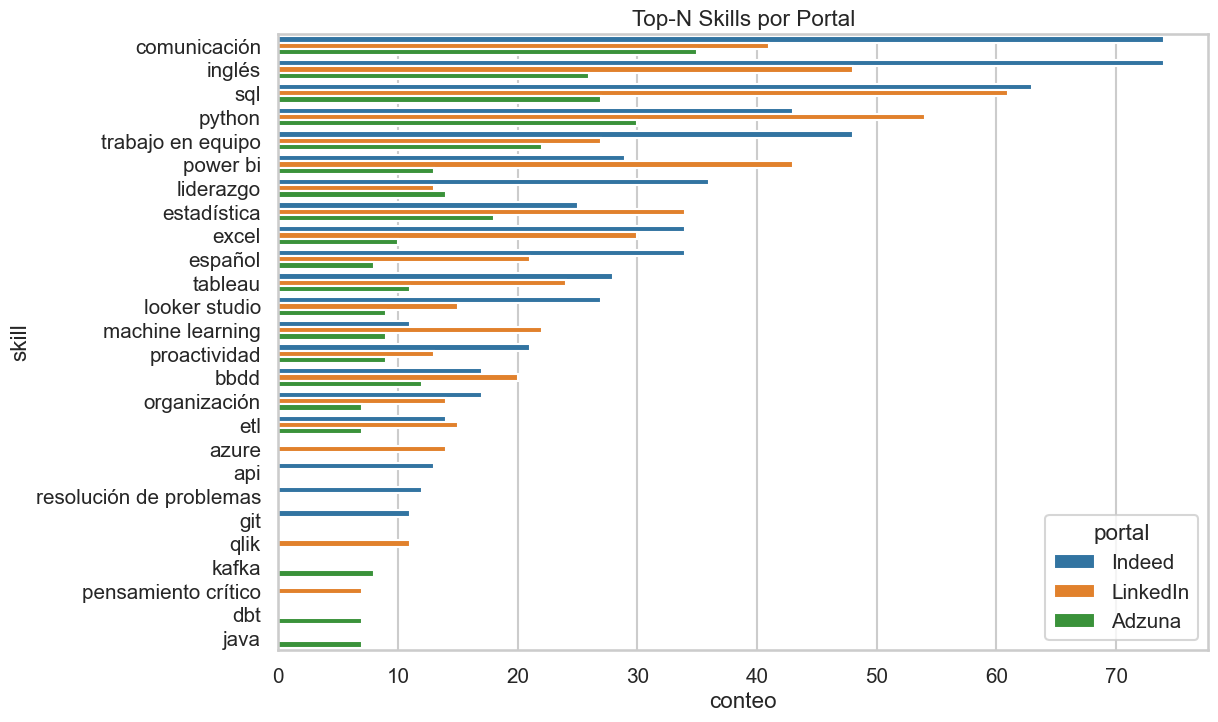

In [ ]:
# Top-N skills por portal
top_n = 20
df_top_skills = (
    df_skills_global_conteo
    .sort_values("conteo", ascending=False)
    .groupby("portal")
    .head(top_n)
)

plt.figure(figsize=(12,8))
sns.barplot(data=df_top_skills, x="conteo", y="skill", hue="portal")
plt.title("Top-N Skills por Portal")
plt.show()


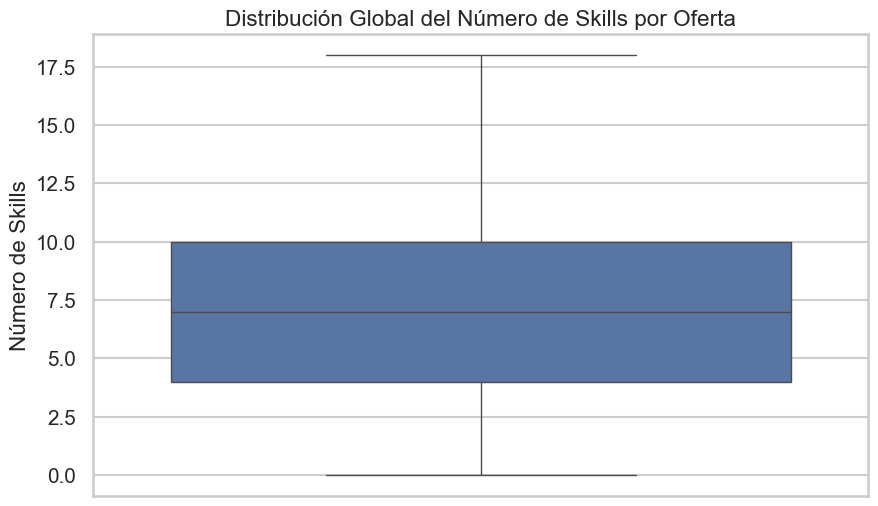

In [ ]:
# Ditribución global del número de skills
df_skills_count = (
    df_skills_ofertas
    .groupby(["portal", "id_oferta"])["skill"]
    .count()
    .reset_index(name="num_skills")
)

plt.figure(figsize=(10,6))
sns.boxplot(data=df_skills_count, y="num_skills", color="#4C72B0")
plt.title("Distribución Global del Número de Skills por Oferta")
plt.ylabel("Número de Skills")
plt.xlabel("")
plt.show()



C:\Users\Usuario\AppData\Local\Temp\ipykernel_4144\1662553173.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


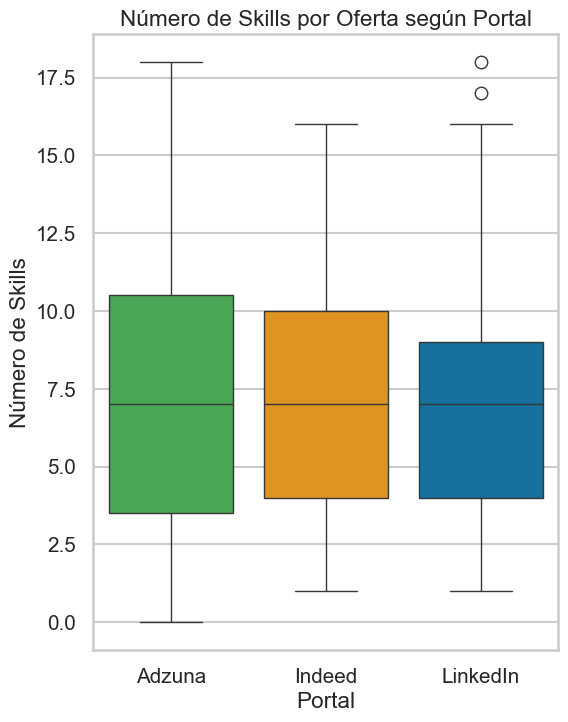

In [ ]:
# Distribución del número de skills por portal
plt.figure(figsize=(6,8))

sns.boxplot(
    data=df_skills_count,
    x="portal",
    y="num_skills",
    palette={
        "LinkedIn": "#0077B5",
        "Adzuna": "#3AB54A",
        "Indeed": "#FF9900"
    }
)

plt.title("Número de Skills por Oferta según Portal")
plt.xlabel("Portal")
plt.ylabel("Número de Skills")
plt.show()


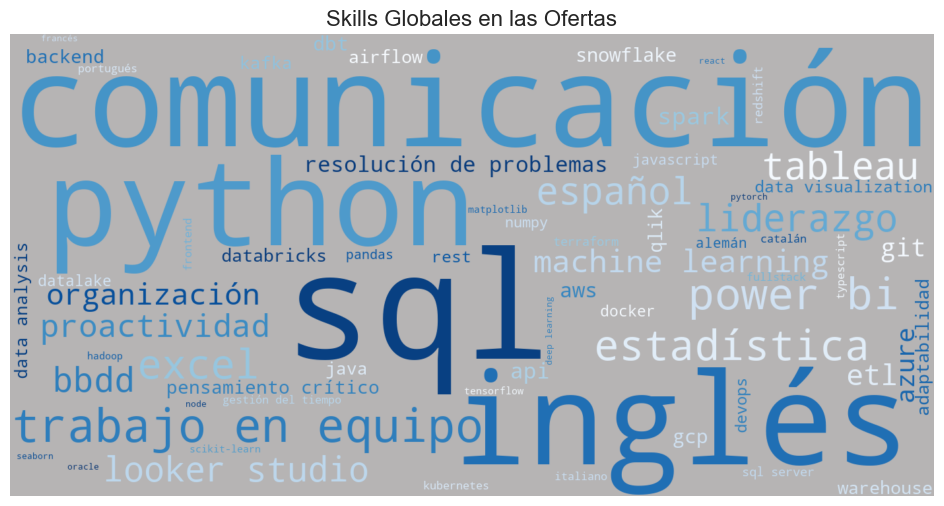

In [114]:
# Wordcloud global
skills_global = df_skills_ofertas["skill"].value_counts(normalize=True)
generar_wordcloud(skills_global, "Skills Globales en las Ofertas", tipo="skill")


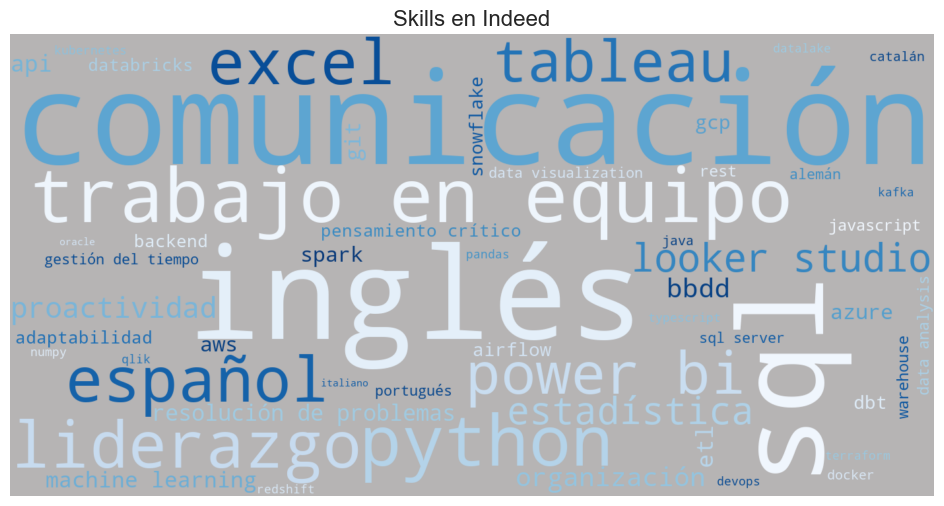

In [ ]:
# Wordcloud para Indeed
skills_indeed = df_skills_ofertas[df_skills_ofertas["portal"]=="Indeed"]["skill"].value_counts(normalize=True)
generar_wordcloud(skills_indeed, "Skills en Indeed", tipo="skill")


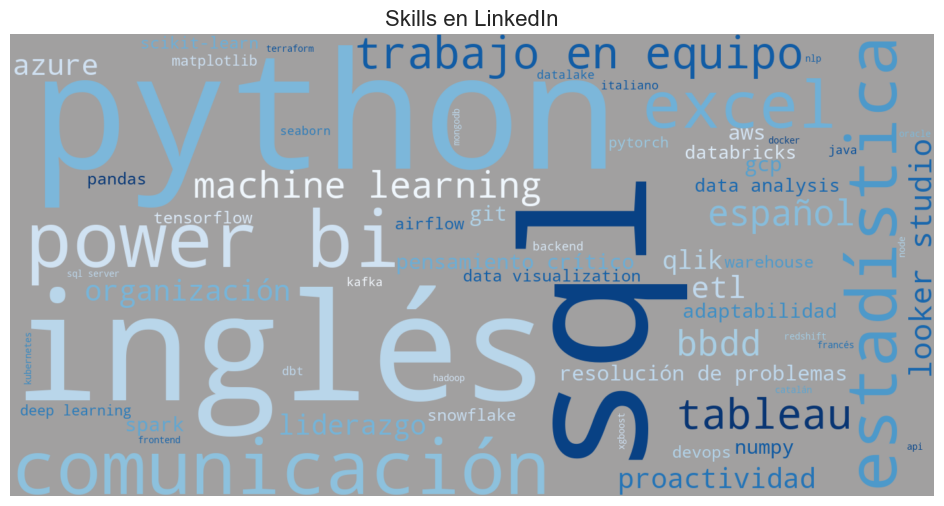

In [ ]:
# Wordcloud para LinkedIn
skills_linkedin = df_skills_ofertas[df_skills_ofertas["portal"]=="LinkedIn"]["skill"].value_counts(normalize=True)
generar_wordcloud(skills_linkedin, "Skills en LinkedIn", tipo="skill")


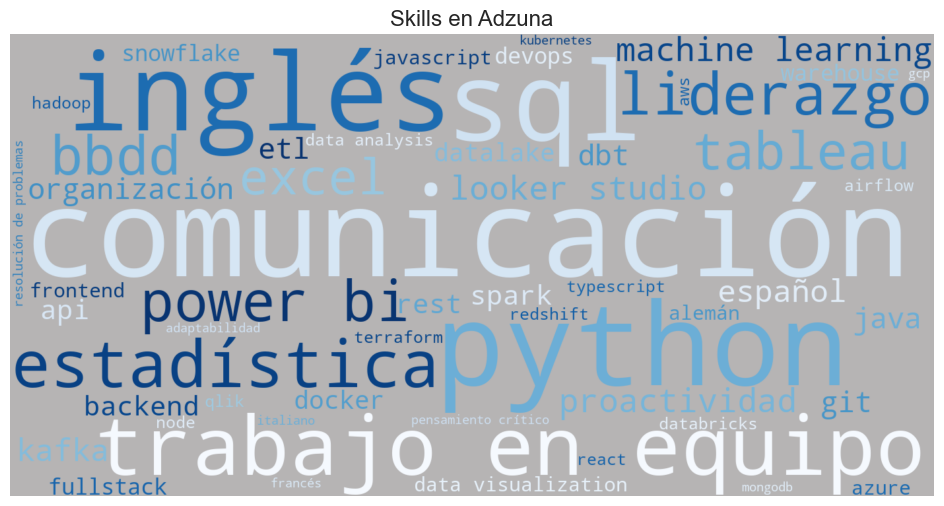

In [ ]:
# Wordcloud para Adzuna
skills_adzuna = df_skills_ofertas[df_skills_ofertas["portal"]=="Adzuna"]["skill"].value_counts(normalize=True)
generar_wordcloud(skills_adzuna, "Skills en Adzuna", tipo="skill")


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4144\2584637338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4144\2584637338.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


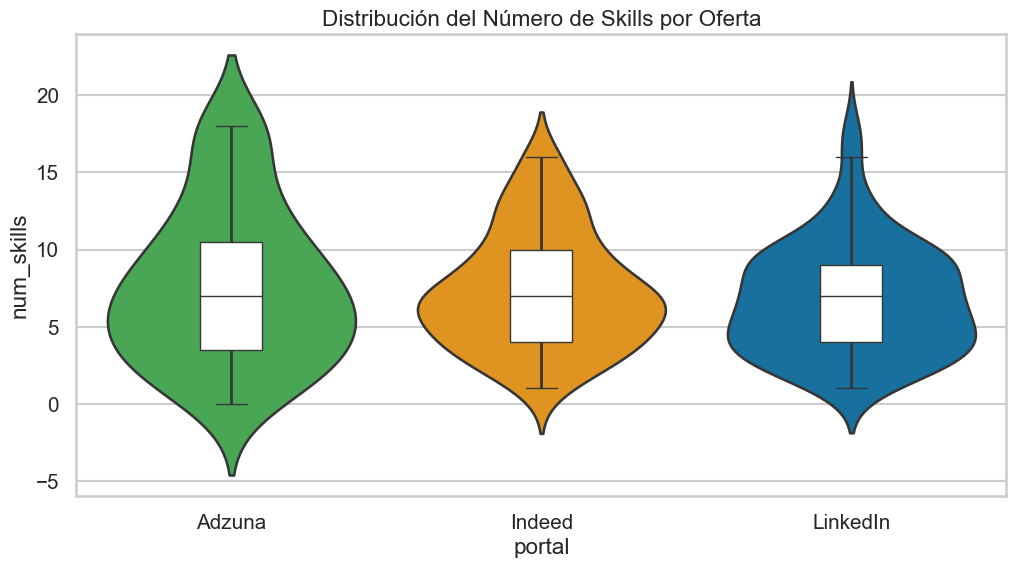

In [ ]:
# Distribución del número de skills por portal
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_skills_count,
    x="portal",
    y="num_skills",
    inner=None,
    palette={"LinkedIn": "#0077B5", "Adzuna": "#3AB54A", "Indeed": "#FF9900"}
)

sns.boxplot(
    data=df_skills_count,
    x="portal",
    y="num_skills",
    width=0.2,
    showcaps=True,
    boxprops={'facecolor':'white'},
    showfliers=False,
    whiskerprops={'linewidth':2},
    palette={"LinkedIn": "#0077B5", "Adzuna": "#3AB54A", "Indeed": "#FF9900"}
)

plt.title("Distribución del Número de Skills por Oferta")
plt.show()


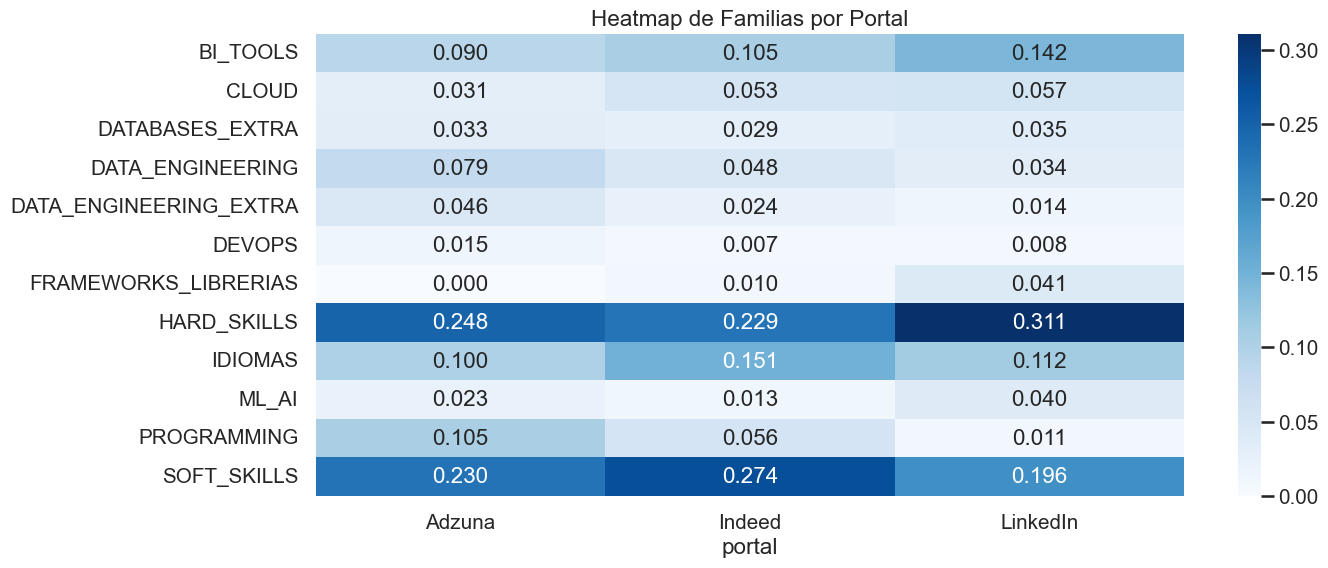

In [147]:
# A2. Heatmap de skills 
plt.figure(figsize=(14,6))
sns.heatmap(tab_familias_pct.T, annot=True, fmt=".3f", cmap="Blues")
plt.title("Heatmap de Familias por Portal")
plt.show()


### SECCIÓN B — Visualización de Familias

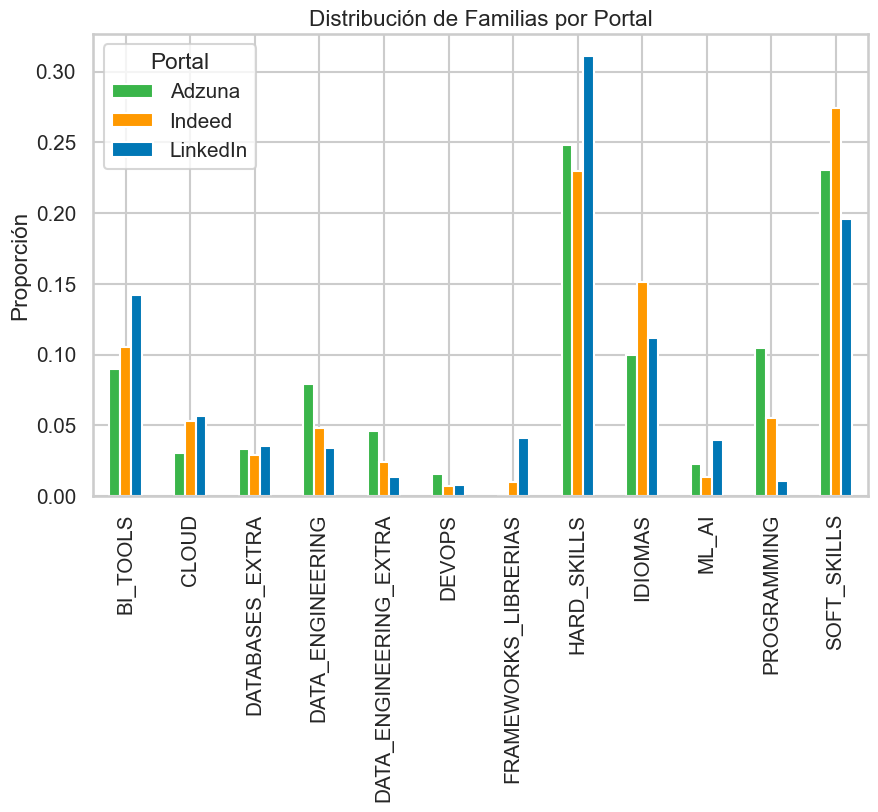

In [141]:
barras_portales(tab_familias_pct, "Distribución de Familias por Portal")

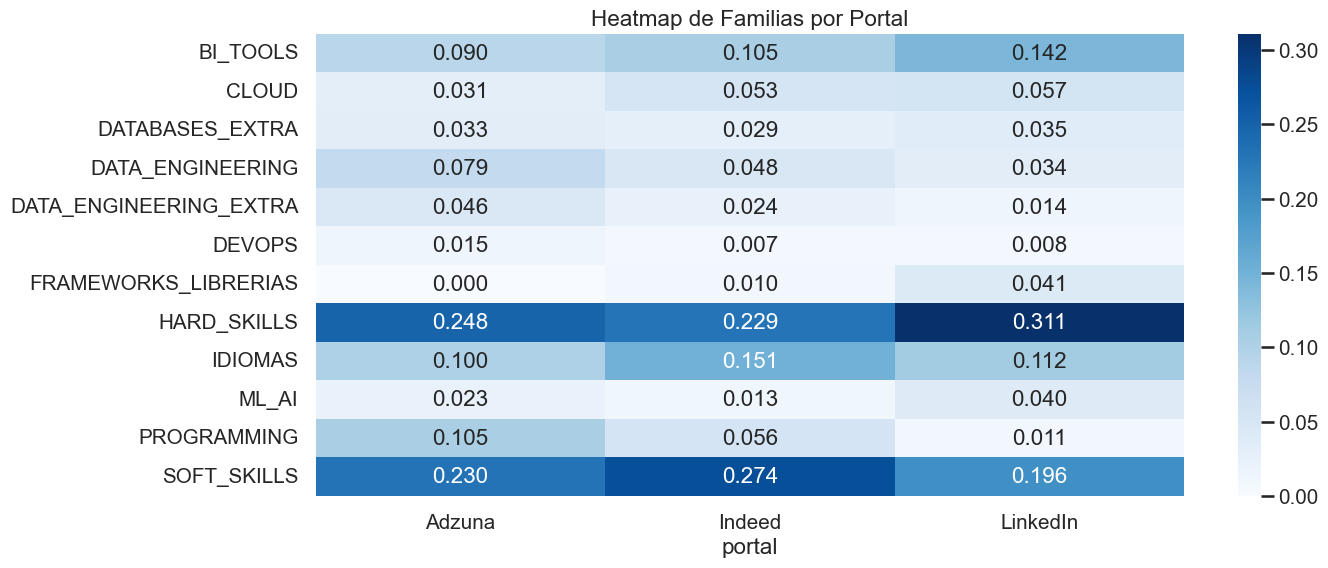

In [139]:
# Heatmap de skills 
plt.figure(figsize=(14,6))
sns.heatmap(tab_familias_pct.T, annot=True, fmt=".3f", cmap="Blues")
plt.title("Heatmap de Familias por Portal")
plt.show()


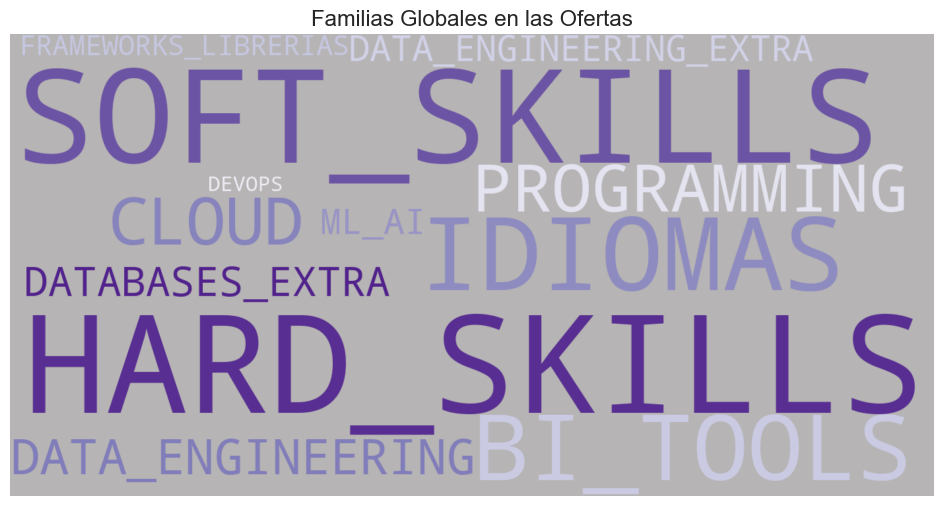

In [ ]:
# Wordcloud Global de Familias de Skills
familias_global = df_fam_req["familia"].value_counts(normalize=True)
generar_wordcloud(
    familias_global,
    "Familias Globales en las Ofertas",
    tipo="familia"
)


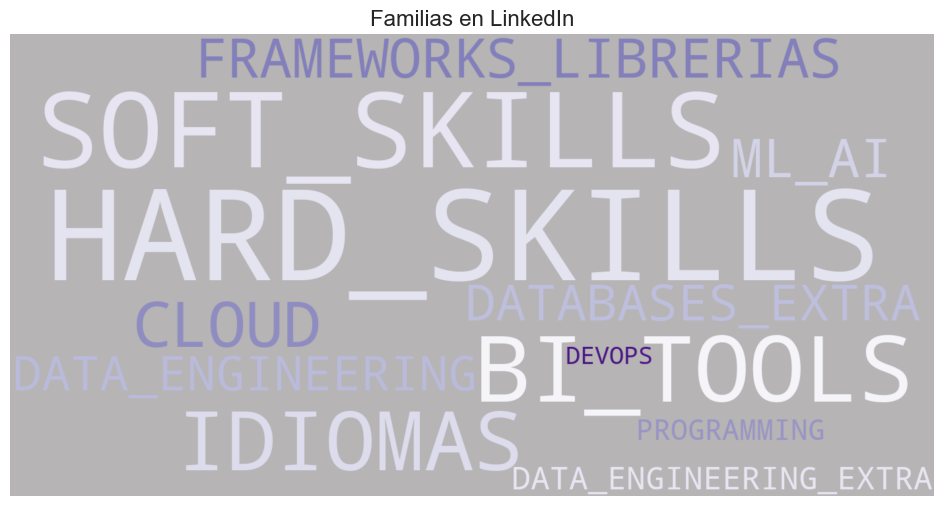

In [ ]:
# Wordcloud Familias LinkedIn
familias_linkedin = df_skills_ofertas[df_skills_ofertas["portal"]=="LinkedIn"]["familia"].value_counts(normalize=True)
generar_wordcloud(familias_linkedin, "Familias en LinkedIn", tipo="familia")

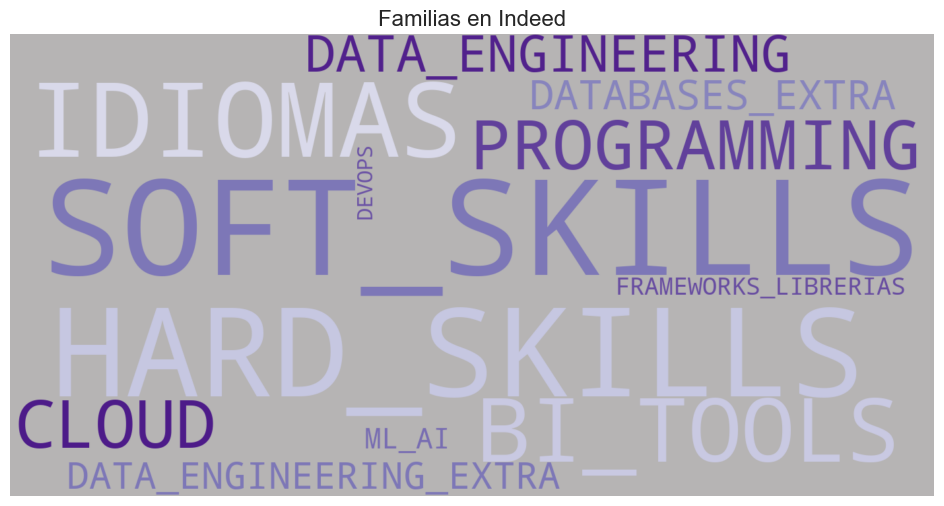

In [ ]:
# Wordcloud Familias Indeed
familias_indeed = df_skills_ofertas[df_skills_ofertas["portal"]=="Indeed"]["familia"].value_counts(normalize=True)
generar_wordcloud(familias_indeed, "Familias en Indeed", tipo="familia")


In [ ]:
# Wordcloud para Adzuna
familias_adzuna = df_skills_ofertas[df_skills_ofertas["portal"]=="Adzuna"]["familia"].value_counts(normalize=True)
generar_wordcloud(familias_adzuna, "Familias en Adzuna", tipo="familia")

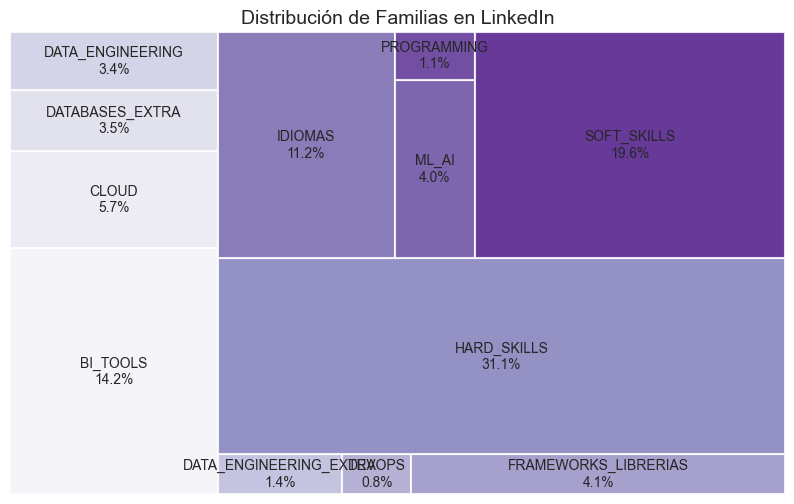

In [ ]:
# Treemap Familias LinkedIn
treemap(tab_familias_pct.loc["LinkedIn"], 
        "Distribución de Familias en LinkedIn", 
        tipo="familia")


<Figure size 1000x600 with 0 Axes>

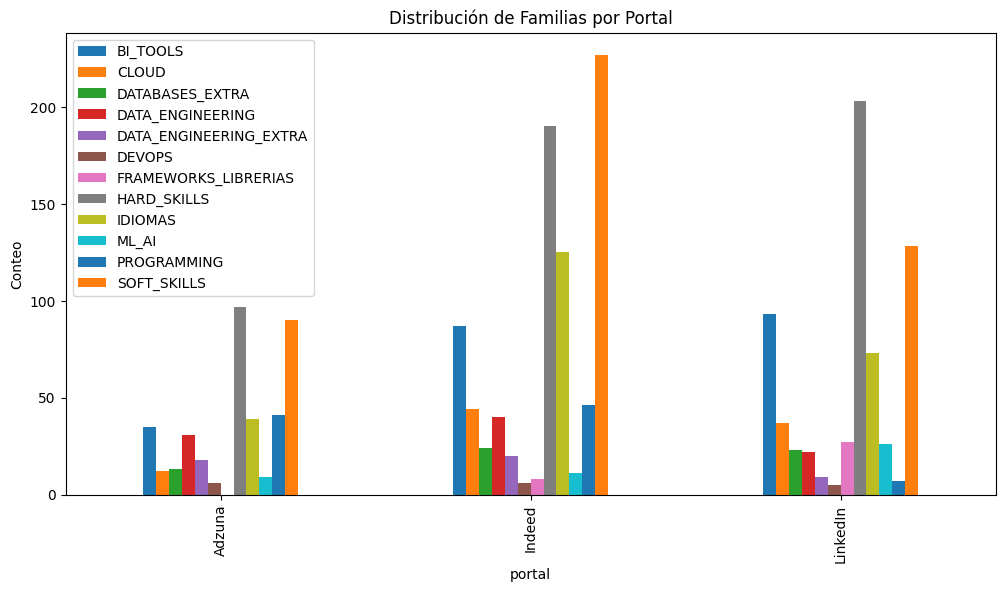

In [ ]:
# Conteo de familias por portal
plt.figure(figsize=(10,6))
tab_familias.plot(kind="bar", figsize=(12,6))
plt.title("Distribución de Familias por Portal")
plt.ylabel("Conteo")
plt.show()


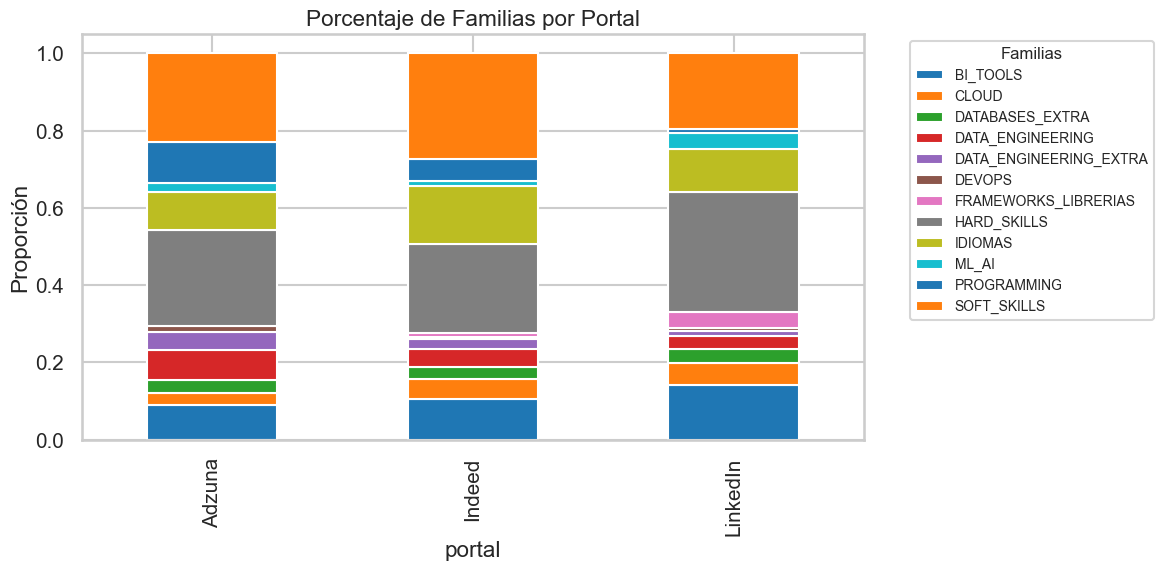

In [ ]:
# Porcentaje de familias por portal
ax = tab_familias_pct.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Porcentaje de Familias por Portal")
plt.ylabel("Proporción")

plt.legend(
    title="Familias",
    fontsize=10,          # ← tamaño del texto de la leyenda
    title_fontsize=12,    # ← tamaño del título de la leyenda
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [42]:
# Función para Radar de Portales por Familias
def radar_portales_familias(df_pct, titulo="Radar de Portales por Familias", figsize=(10,10)):
    categorias = df_pct.columns.tolist()
    N = len(categorias)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    colores = {
        "LinkedIn": "#0077B5",
        "Adzuna": "#3AB54A",
        "Indeed": "#FF9900"
    }

    plt.figure(figsize=figsize)
    ax = plt.subplot(111, polar=True)

    for portal, row in df_pct.iterrows():
        valores = row.tolist()
        valores += valores[:1]
        ax.plot(angles, valores, linewidth=2, label=portal, color=colores.get(portal, "grey"))
        ax.fill(angles, valores, alpha=0.15, color=colores.get(portal, "grey"))

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categorias, fontsize=9)
    ax.set_title(titulo, size=14, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

    plt.show()


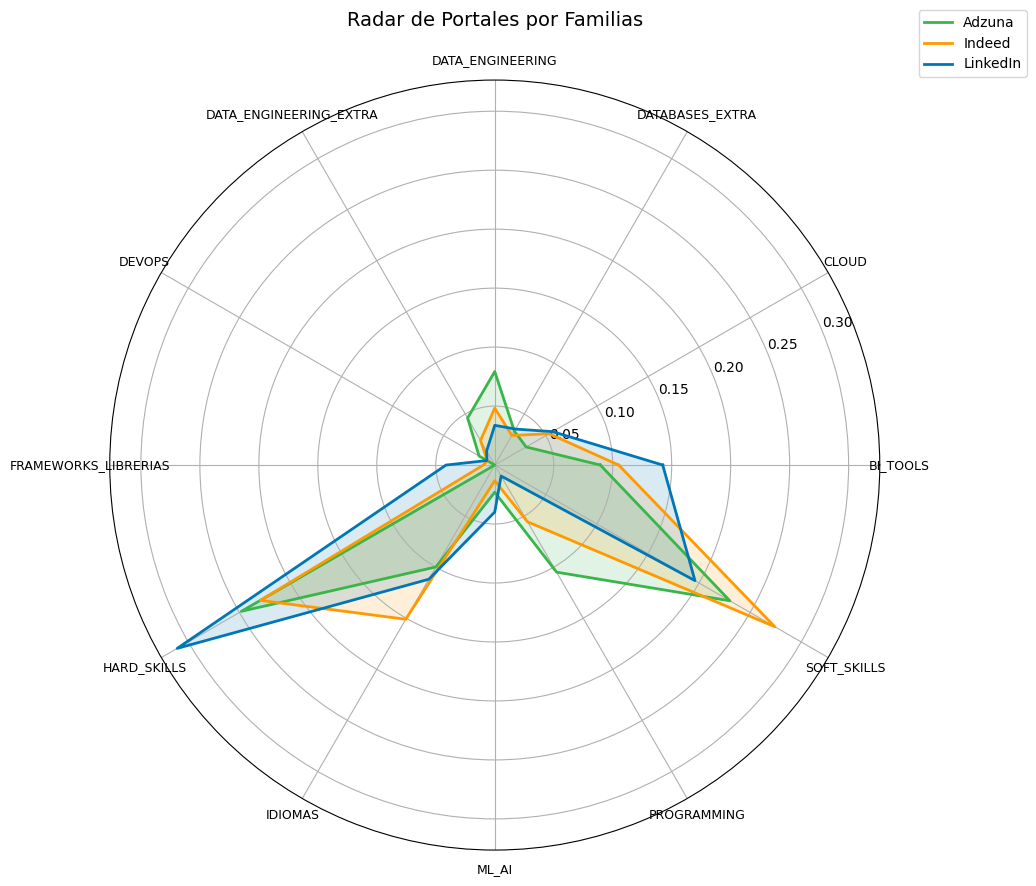

In [ ]:
# Radar chart 
radar_portales_familias(tab_familias_pct)


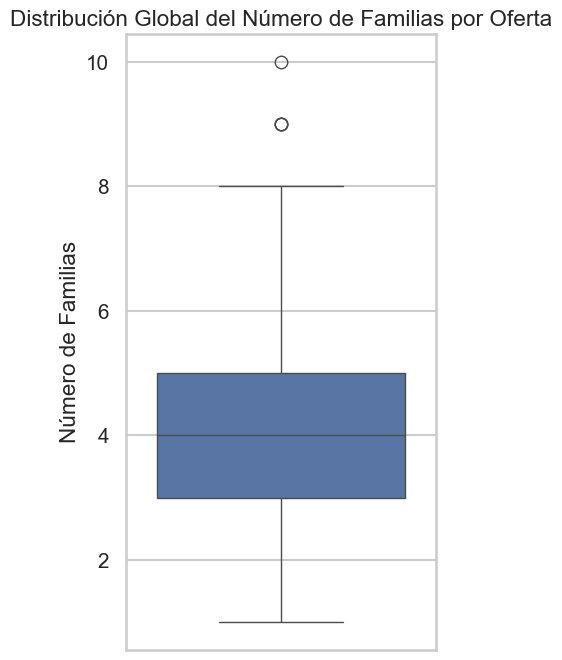

In [133]:
df_fam_count = (
    df_fam_req
    .groupby(["portal", "id_oferta"])["familia"]
    .nunique()
    .reset_index(name="num_familias")
)
plt.figure(figsize=(4,8))
sns.boxplot(
    data=df_fam_count,
    y="num_familias",
    color="#4C72B0"
)
plt.title("Distribución Global del Número de Familias por Oferta")
plt.ylabel("Número de Familias")
plt.xlabel("")
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4144\388296574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


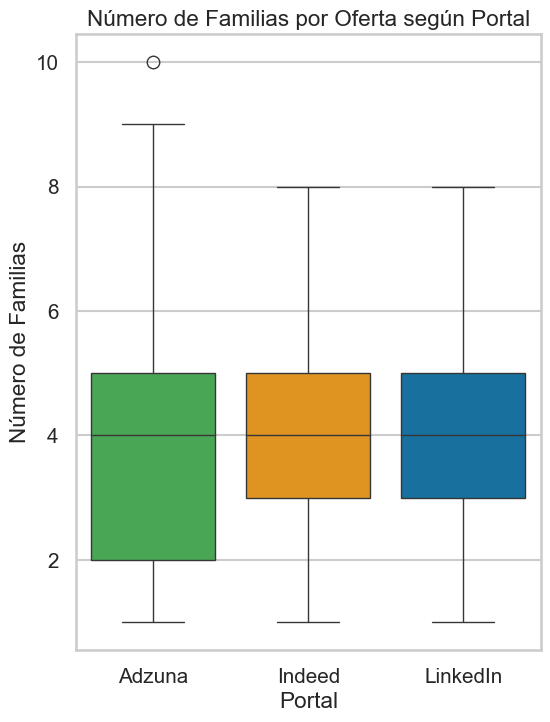

In [148]:
plt.figure(figsize=(6,8))

sns.boxplot(
    data=df_fam_count,
    x="portal",
    y="num_familias",
    palette={
        "LinkedIn": "#0077B5",
        "Adzuna": "#3AB54A",
        "Indeed": "#FF9900"
    }
)

plt.title("Número de Familias por Oferta según Portal")
plt.xlabel("Portal")
plt.ylabel("Número de Familias")
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4144\1125763249.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4144\1125763249.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


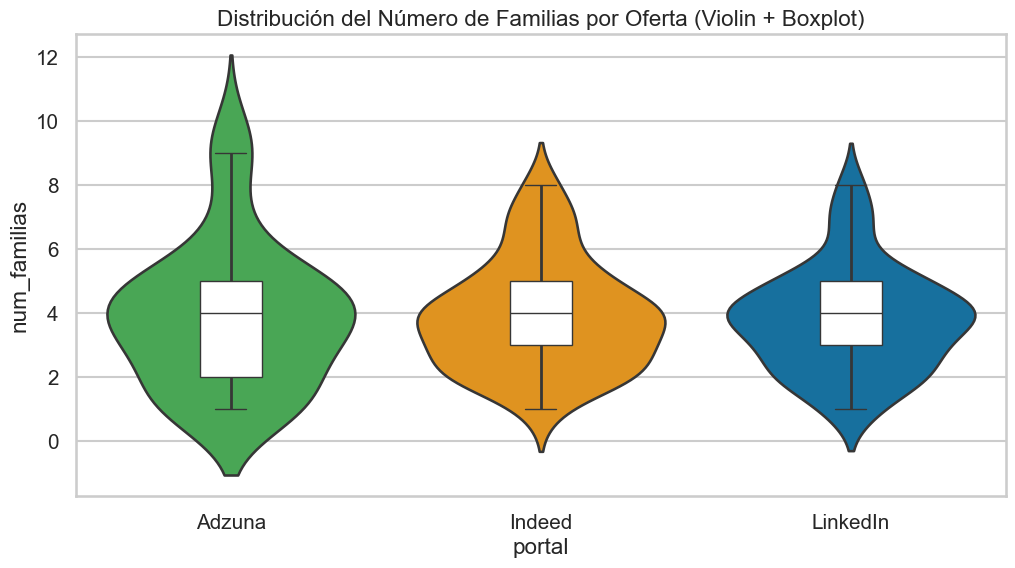

In [122]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_fam_count,
    x="portal",
    y="num_familias",
    inner=None,
    palette={
        "LinkedIn": "#0077B5",
        "Adzuna": "#3AB54A",
        "Indeed": "#FF9900"
    }
)

sns.boxplot(
    data=df_fam_count,
    x="portal",
    y="num_familias",
    width=0.2,
    showcaps=True,
    boxprops={'facecolor':'white'},
    showfliers=False,
    whiskerprops={'linewidth':2},
    palette={
        "LinkedIn": "#0077B5",
        "Adzuna": "#3AB54A",
        "Indeed": "#FF9900"
    }
)

plt.title("Distribución del Número de Familias por Oferta (Violin + Boxplot)")
plt.show()


### SECCIÓN C — Visualización de Requisitos

In [46]:
def heatmap_requisito(df_pct, requisito, titulo=None):
    paleta = PALETAS_REQUISITOS.get(requisito, "Oranges")
    titulo = titulo or f"Heatmap de {requisito}"

    plt.figure(figsize=TAM_FIGURA)
    sns.heatmap(df_pct, annot=True, cmap=paleta, fmt=".2f")
    plt.title(titulo)
    plt.show()


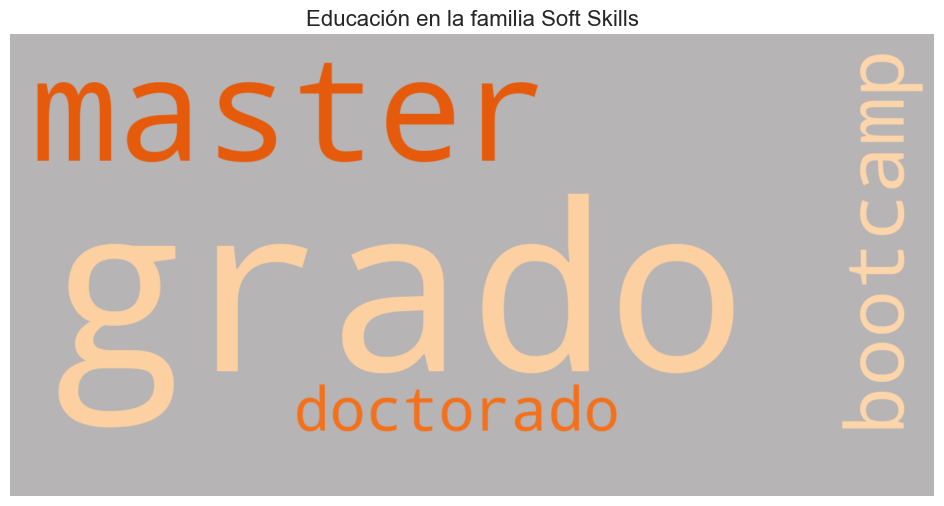

In [98]:
educacion_softskills = df_fam_req[df_fam_req["familia"]=="SOFT_SKILLS"]["educacion_nlp"].value_counts(normalize=True)
generar_wordcloud(educacion_softskills, "Educación en la familia Soft Skills", tipo="requisito")


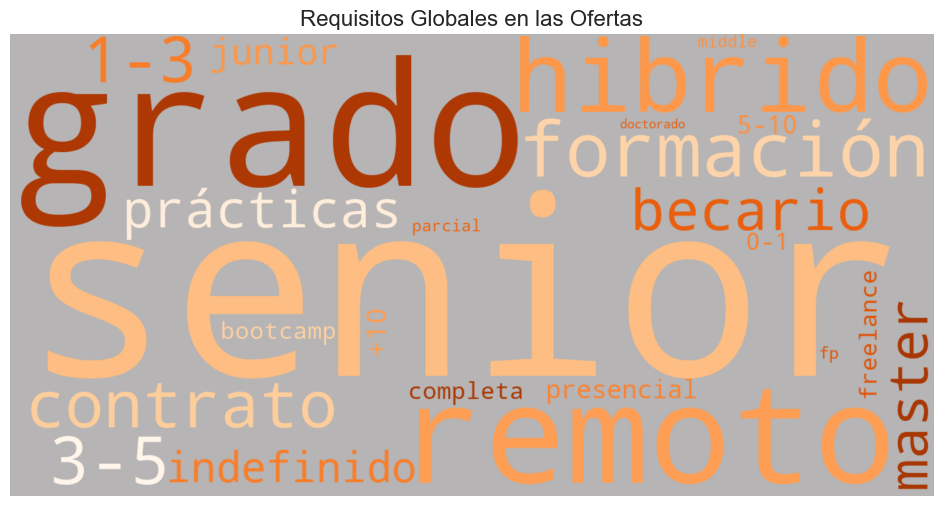

In [92]:
requisitos_cols = [
    "modalidad_nlp",
    "contrato_nlp",
    "jornada_nlp",
    "educacion_nlp",
    "experiencia_bin",
    "experiencia_nivel_nlp"
]

# Unificar todas las columnas en una sola serie
requisitos_global = (
    df_requisitos[requisitos_cols]
    .melt(value_name="requisito")["requisito"]
    .value_counts(normalize=True)
)

generar_wordcloud(
    requisitos_global,
    "Requisitos Globales en las Ofertas",
    tipo="requisito"
)


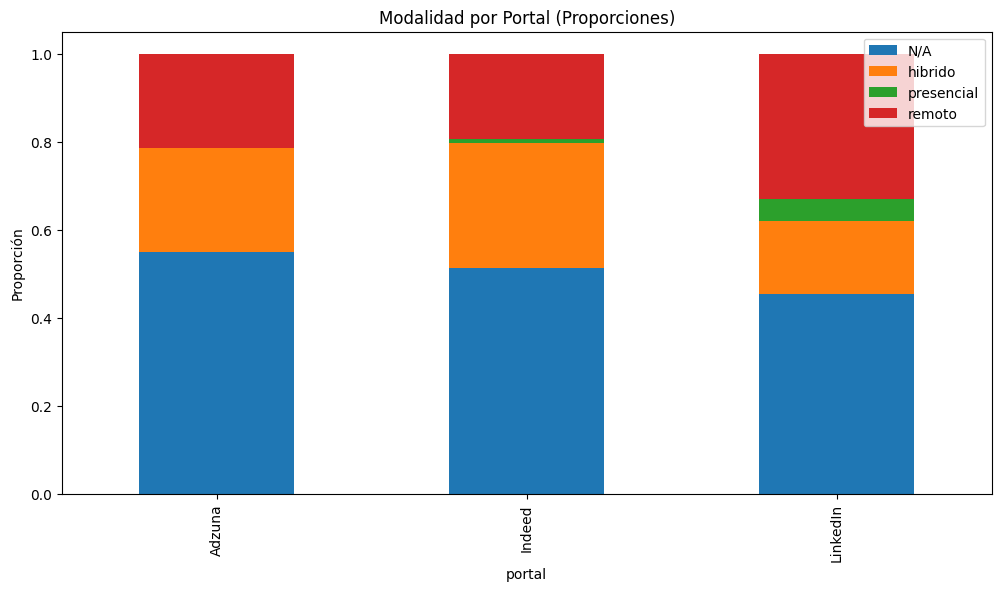

In [ ]:
# Modalidad por portal
tab_modalidad_pct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Modalidad por Portal (Proporciones)")
plt.ylabel("Proporción")
plt.show()


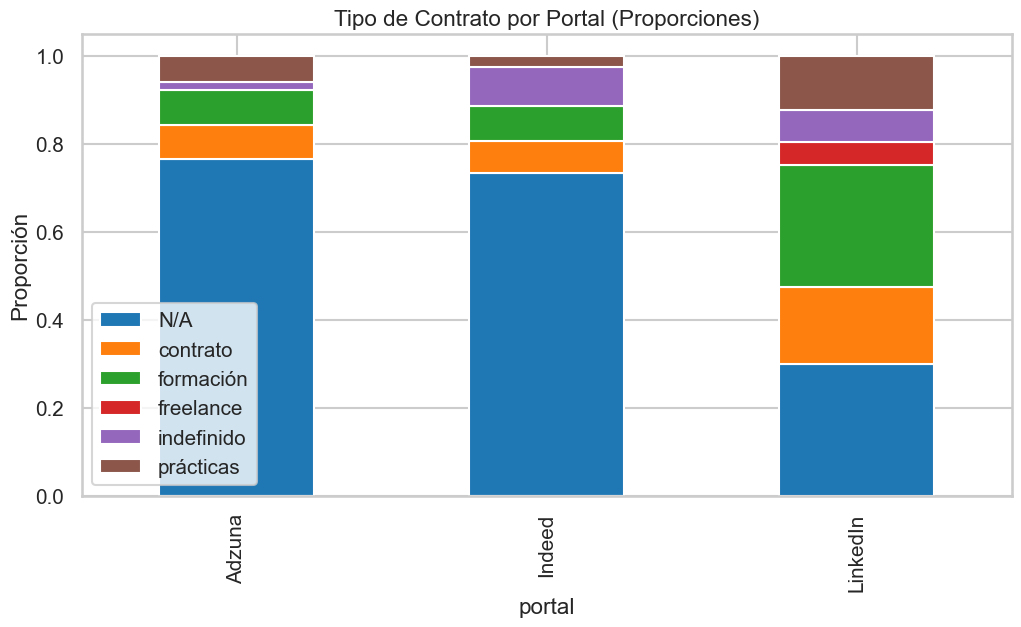

In [150]:
# C2. Contrato por portal
tab_contrato_pct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Tipo de Contrato por Portal (Proporciones)")
plt.ylabel("Proporción")
plt.show()


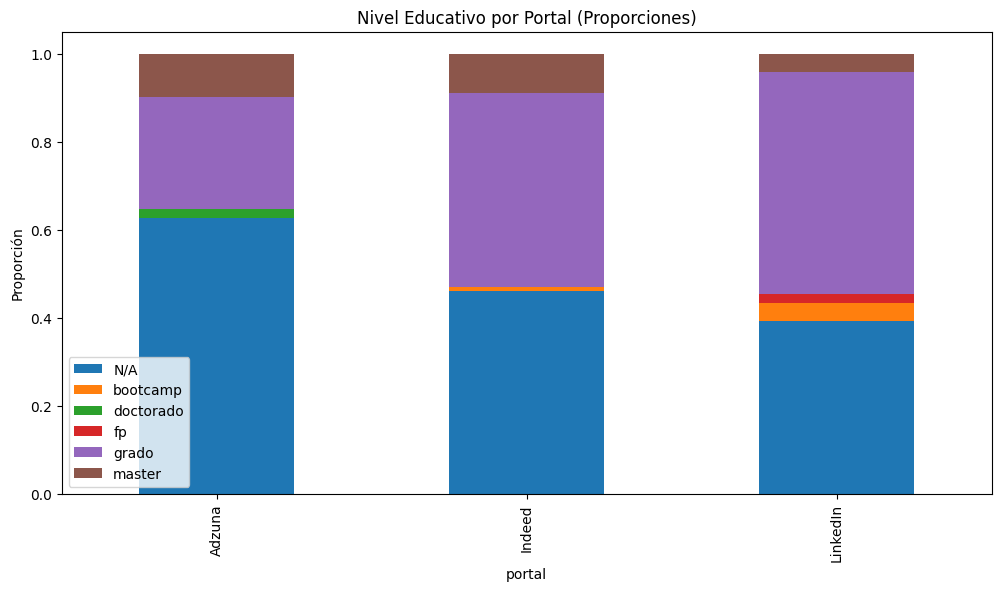

In [ ]:
# Educación por portal
tab_educacion_pct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Nivel Educativo por Portal (Proporciones)")
plt.ylabel("Proporción")
plt.show()


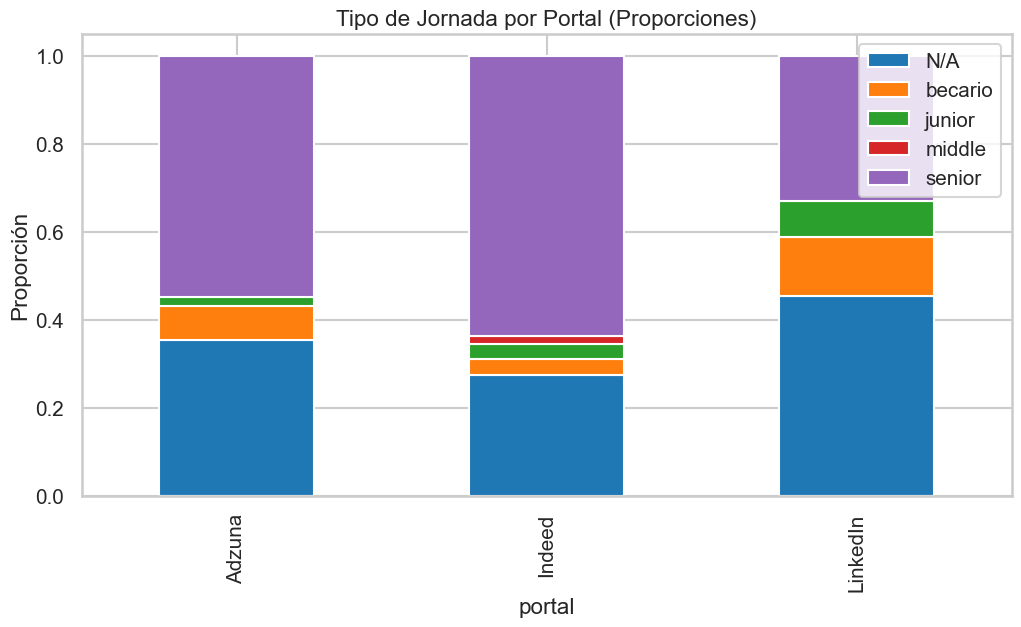

In [ ]:
# Jornada por portal
tab_nivel_exp_pct.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Tipo de Jornada por Portal (Proporciones)")
plt.ylabel("Proporción")
plt.show()

### SECCIÓN D — Cruce Familias ↔ Requisitos

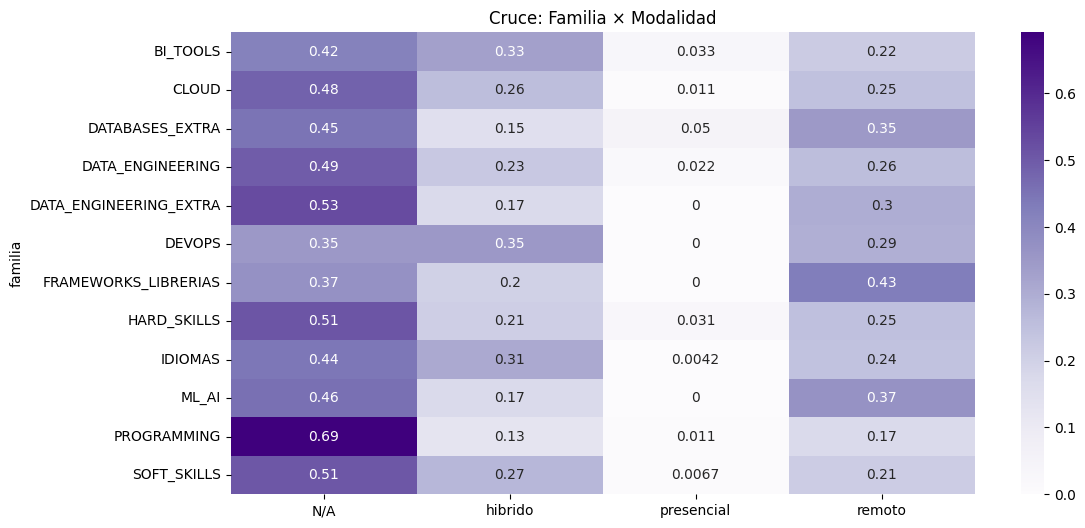

In [ ]:
# Cruce: Familia × Modalidad
plt.figure(figsize=(12,6))
sns.heatmap(tabla_fam_modalidad_pct, annot=True, cmap="Purples")
plt.title("Cruce: Familia × Modalidad")
plt.show()


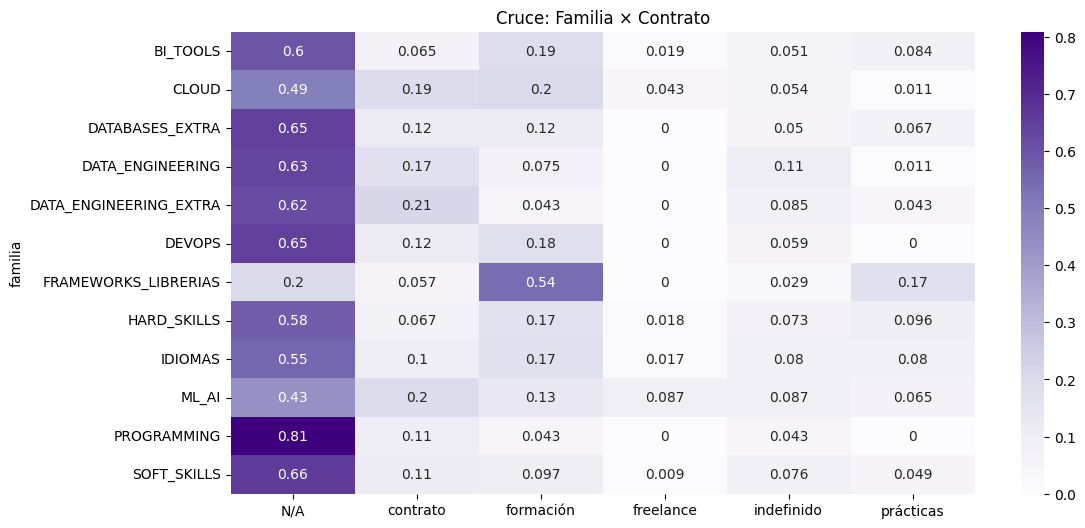

In [ ]:
# Cruce: Familia × Contrato
plt.figure(figsize=(12,6))
sns.heatmap(tabla_fam_contrato_pct, annot=True, cmap="Purples")
plt.title("Cruce: Familia × Contrato")
plt.show()

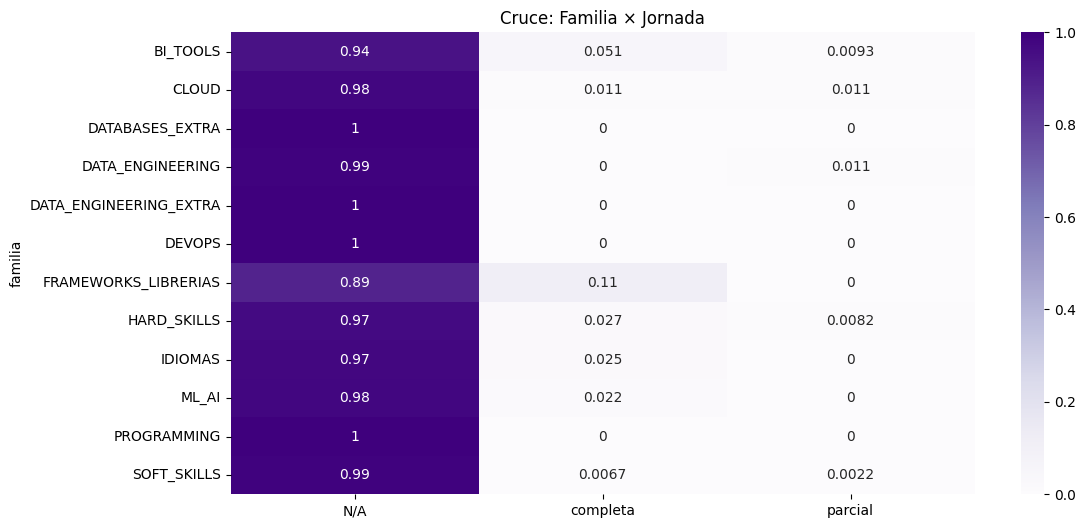

In [ ]:
# Cruce: Familia × Jornada
plt.figure(figsize=(12,6))
sns.heatmap(tabla_fam_jornada_pct, annot=True, cmap="Purples")
plt.title("Cruce: Familia × Jornada")
plt.show()

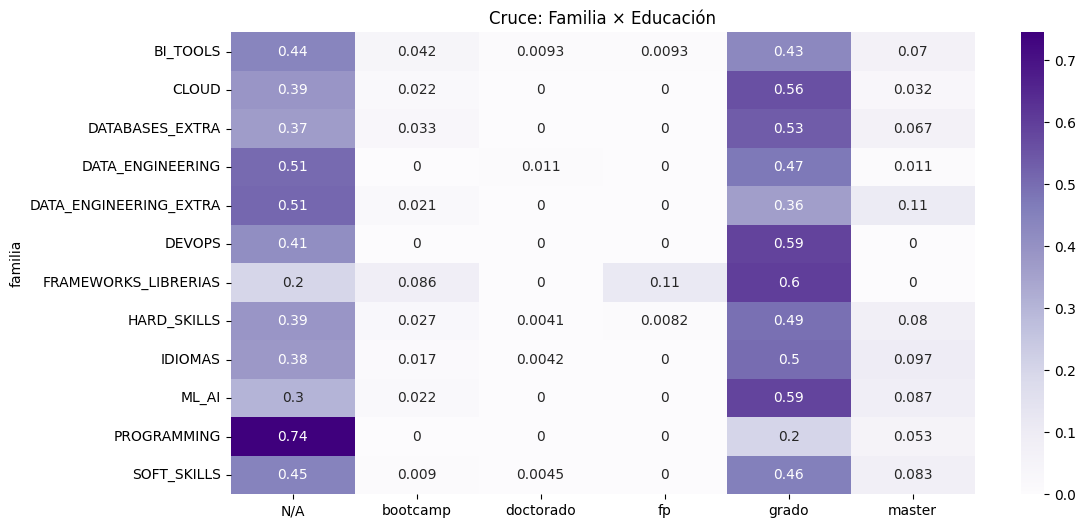

In [ ]:
# Cruce: Familia × Educación
plt.figure(figsize=(12,6))
sns.heatmap(tabla_fam_educacion_pct, annot=True, cmap="Purples")
plt.title("Cruce: Familia × Educación")
plt.show()

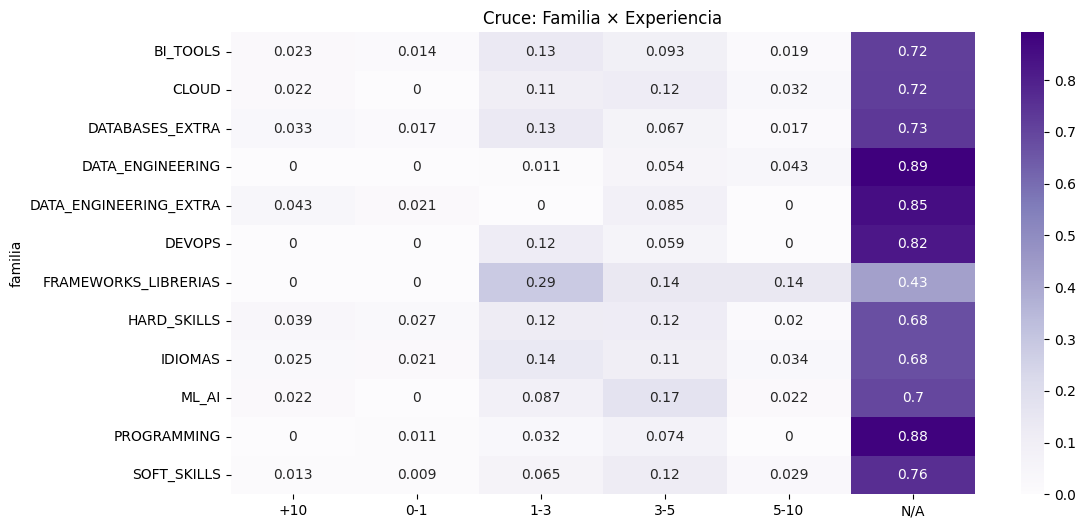

In [ ]:
# Cruce: Familia × Experiencia
plt.figure(figsize=(12,6))
sns.heatmap(tabla_fam_experiencia_pct, annot=True, cmap="Purples")
plt.title("Cruce: Familia × Experiencia")
plt.show()

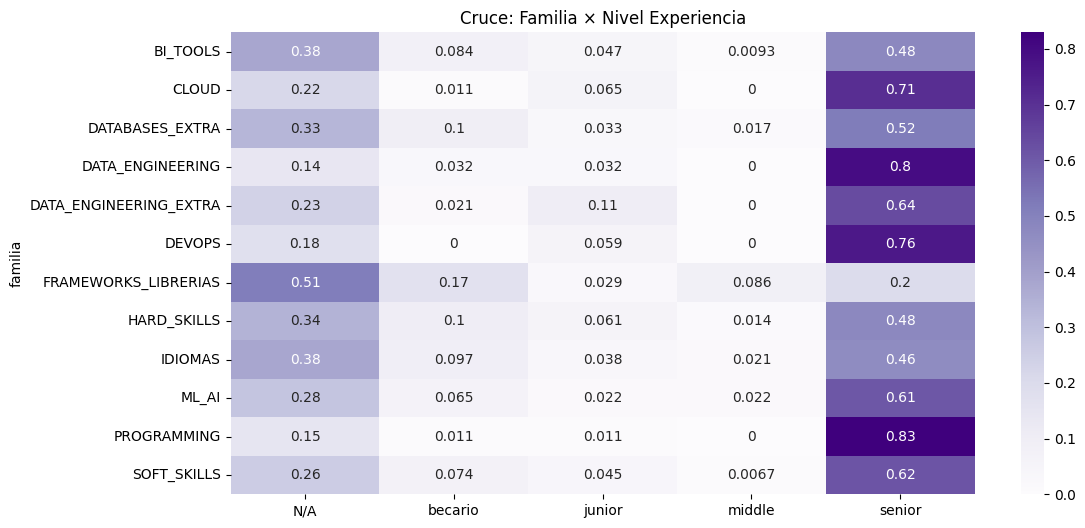

In [ ]:
# Cruce: Familia × Nivel Experiencia
plt.figure(figsize=(12,6))
sns.heatmap(tabla_fam_nivel_exp_pct, annot=True, cmap="Purples")
plt.title("Cruce: Familia × Nivel Experiencia")
plt.show()
